Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)


/Users/vemula/myenv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)


--- Training Deep Neural Network (DNN) ---
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9241 - loss: 0.2499 - val_accuracy: 0.9652 - val_loss: 0.1171
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9643 - loss: 0.1196 - val_accuracy: 0.9742 - val_loss: 0.0888
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9716 - loss: 0.0950 - val_accuracy: 0.9732 - val_loss: 0.0882
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9763 - loss: 0.0779 - val_accuracy: 0.9802 - val_loss: 0.0754
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9792 - loss: 0.0675 - val_accuracy: 0.9797 - val_loss: 0.0749
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9820 - loss: 0.0577 - val_accuracy: 0.9757 - val_loss: 0.0850
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9831 - loss: 0.0534 - val_accuracy: 0.9793 - val_loss: 0.0764
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4

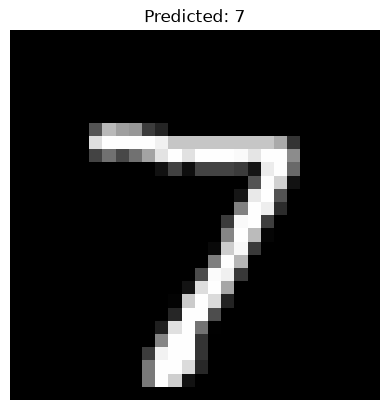

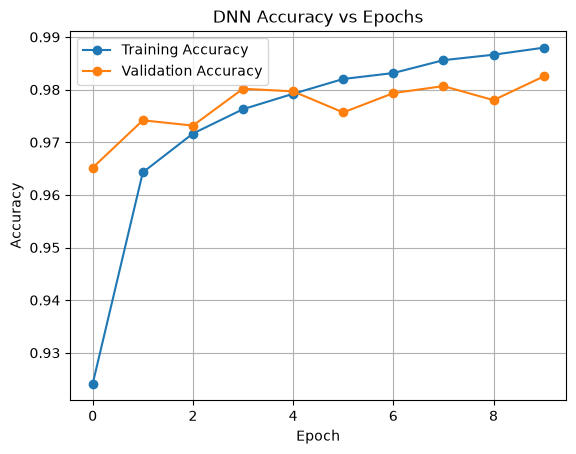

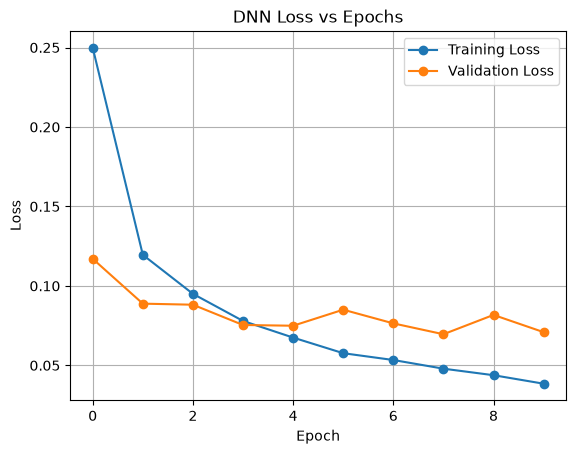

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step


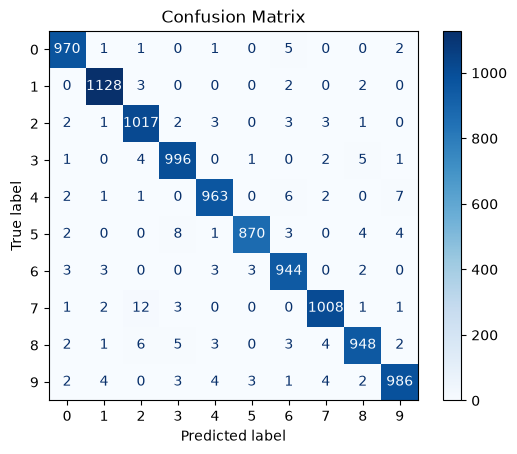

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training Images Shape:", X_train.shape)
print("Testing Images Shape:", X_test.shape)

dnn_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),  
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

dnn_model.summary()

dnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Training Deep Neural Network (DNN) ---")

history = dnn_model.fit(
    X_train,
    y_train,
    epochs=10,               
    validation_split=0.1
)

print("\n--- Evaluating DNN ---")

test_loss, test_acc = dnn_model.evaluate(X_test, y_test)

print(f"\nDNN Test Accuracy: {test_acc * 100:.2f}%")

sample = X_test[0]
prediction = dnn_model.predict(sample.reshape(1, 28, 28))

predicted_digit = np.argmax(prediction)

print("Actual Digit:", y_test[0])
print("Predicted Digit:", predicted_digit)

plt.imshow(sample, cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show()

plt.figure()

plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title('DNN Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

plt.figure()

plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')

plt.title('DNN Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

y_pred = dnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()